<a href="https://colab.research.google.com/github/Asim-Khurshid/-Reconnaissance-Tool/blob/main/AI__Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle imbalanced-learn xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00


In [2]:
!pip install tensorflow -q
import tensorflow as tf

if not tf.test.is_built_with_cuda():
    print("TensorFlow installed without CUDA support.")
else:
    print("TensorFlow with CUDA is installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 767.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow with CUDA is installed.


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asimkhurshid","key":"70d96eb3e335ef36f49f0c74e3817b08"}'}

In [4]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q creditcardfraud.zip
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 292MB/s]

Dataset downloaded!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import xgboost as xgb

# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.21.0
All libraries loaded successfully!


DATASET OVERVIEW
Shape           : (284807, 31)
Total Features  : 30
Missing Values  : 0
Duplicate Rows  : 1081

Class Distribution (original):
  Normal (0) : 284,315  (99.83%)
  Fraud  (1) : 492  (0.17%)


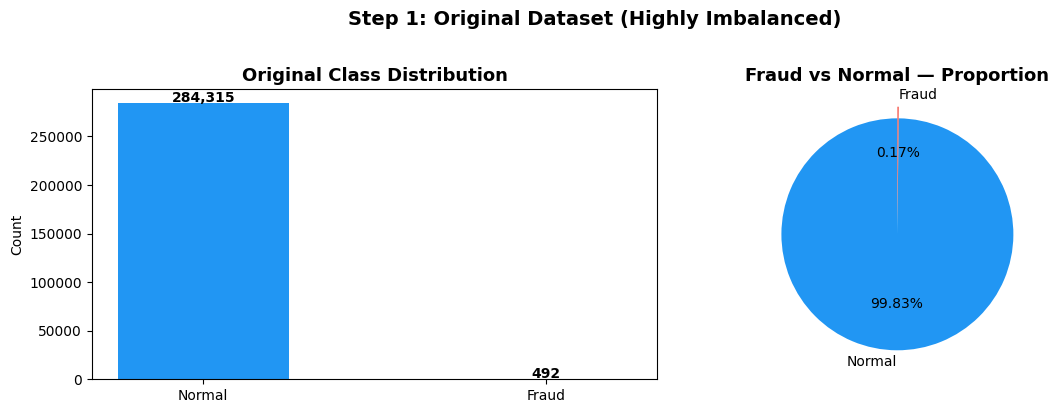

In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — LOAD & EXPLORE DATASET                        ║
# ╚══════════════════════════════════════════════════════════╝
df = pd.read_csv("creditcard.csv")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape           : {df.shape}")
print(f"Total Features  : {df.shape[1] - 1}")
print(f"Missing Values  : {df.isnull().sum().sum()}")
print(f"Duplicate Rows  : {df.duplicated().sum()}")

print("\nClass Distribution (original):")
vc = df['Class'].value_counts()
print(f"  Normal (0) : {vc[0]:,}  ({vc[0]/len(df)*100:.2f}%)")
print(f"  Fraud  (1) : {vc[1]:,}  ({vc[1]/len(df)*100:.2f}%)")

# Visualize original imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal', 'Fraud'], [vc[0], vc[1]], color=['#2196F3', '#F44336'], width=0.5)
axes[0].set_title('Original Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([vc[0], vc[1]], labels=['Normal', 'Fraud'],
            colors=['#2196F3', '#F44336'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud vs Normal — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Step 1: Original Dataset (Highly Imbalanced)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


EXPLORATORY DATA ANALYSIS
            Time         V1         V2         V3         V4         V5  \
count  284807.00  284807.00  284807.00  284807.00  284807.00  284807.00   
mean    94813.86       0.00       0.00      -0.00       0.00       0.00   
std     47488.15       1.96       1.65       1.52       1.42       1.38   
min         0.00     -56.41     -72.72     -48.33      -5.68    -113.74   
25%     54201.50      -0.92      -0.60      -0.89      -0.85      -0.69   
50%     84692.00       0.02       0.07       0.18      -0.02      -0.05   
75%    139320.50       1.32       0.80       1.03       0.74       0.61   
max    172792.00       2.45      22.06       9.38      16.88      34.80   

              V6         V7         V8         V9  ...        V21        V22  \
count  284807.00  284807.00  284807.00  284807.00  ...  284807.00  284807.00   
mean        0.00      -0.00       0.00      -0.00  ...       0.00      -0.00   
std         1.33       1.24       1.19       1.10  ...    

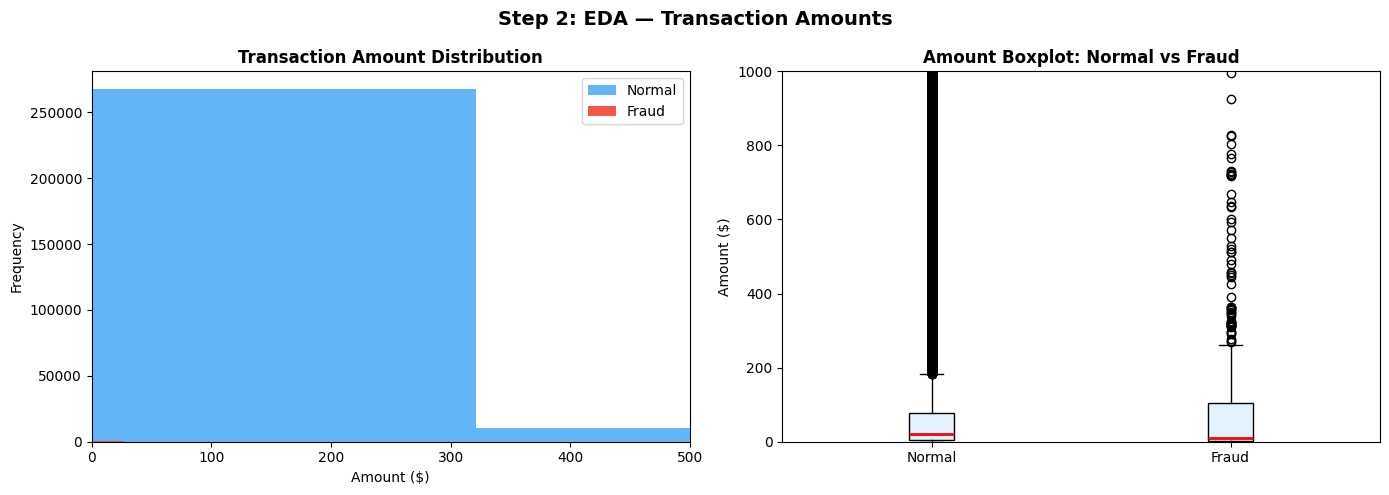


Top 10 Features Correlated with Fraud:
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


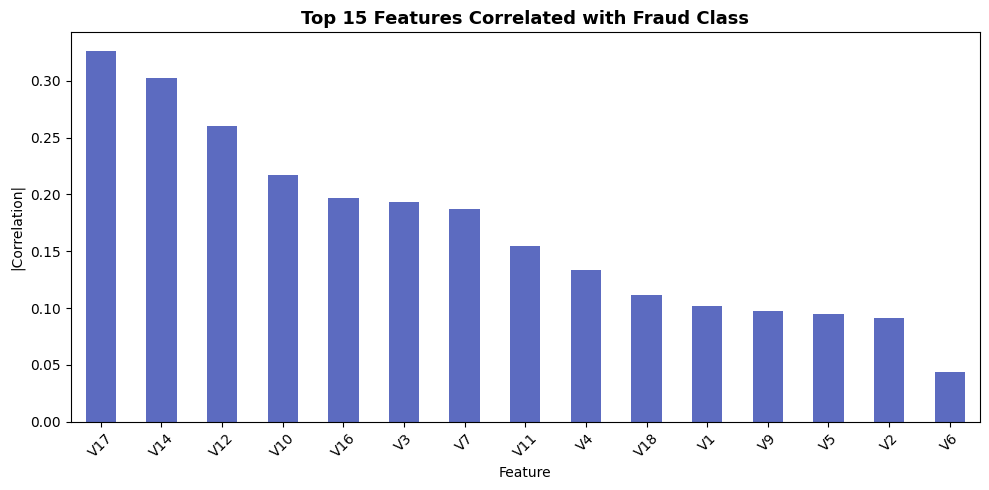

In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — EDA (EXPLORATORY DATA ANALYSIS)               ║
# ╚══════════════════════════════════════════════════════════╝
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)
print(df.describe().round(2))

# Transaction Amount: Fraud vs Normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_amt = df[df['Class'] == 0]['Amount']
fraud_amt  = df[df['Class'] == 1]['Amount']

axes[0].hist(normal_amt, bins=80, color='#2196F3', alpha=0.7, label='Normal')
axes[0].hist(fraud_amt,  bins=80, color='#F44336', alpha=0.9, label='Fraud')
axes[0].set_xlim(0, 500)
axes[0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Fraud amount boxplot
axes[1].boxplot([normal_amt, fraud_amt], labels=['Normal', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Boxplot: Normal vs Fraud', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 1000)

plt.suptitle('Step 2: EDA — Transaction Amounts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlating features with fraud
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("\nTop 10 Features Correlated with Fraud:")
print(corr.head(10).round(4))

plt.figure(figsize=(10, 5))
corr.head(15).plot(kind='bar', color='#5C6BC0')
plt.title('Top 15 Features Correlated with Fraud Class', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — PREPROCESSING                                 ║
# ╚══════════════════════════════════════════════════════════╝
# Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

# Scale Amount and Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])

print("Amount and Time scaled with StandardScaler")
print("Preprocessing complete!")

After removing duplicates: (283726, 31)
Amount and Time scaled with StandardScaler
Preprocessing complete!


In [10]:
!pip install imbalanced-learn

CREATING BALANCED DATASET — 2,00,000 samples
Training samples before balancing : 226,980
Training samples after  balancing : 453,204

Class distribution after SMOTETomek:
  Normal (0): 226,602
  Fraud  (1): 226,602

Test set size: 56,746 (original, untouched)

Trimmed to exactly 200,000:
  Normal (0): 100,000
  Fraud  (1): 100,000


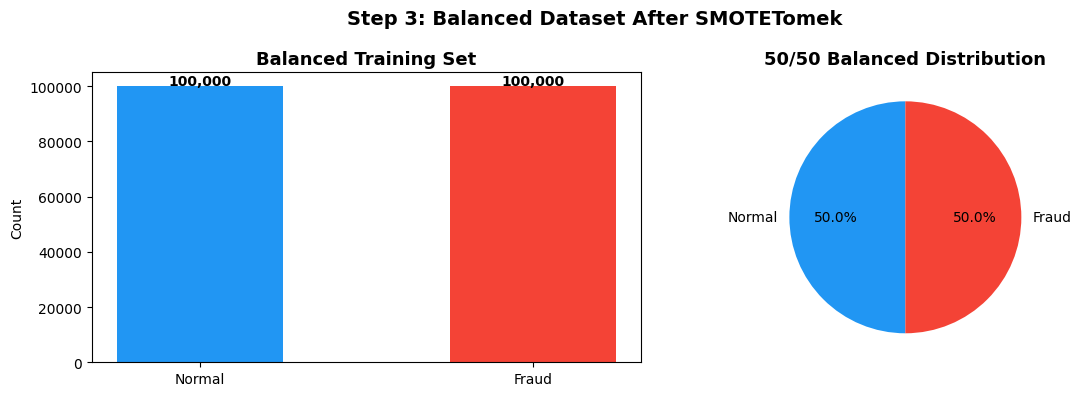


Final training data: (200000, 30)
Final testing  data: (56746, 30)


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — CREATE BALANCED DATASET (2,00,000 samples)    ║
# ╚══════════════════════════════════════════════════════════╝
import numpy as np
from imblearn.combine import SMOTETomek

print("CREATING BALANCED DATASET — 2,00,000 samples")
print("=" * 50)

X = df.drop('Class', axis=1)
y = df['Class']

# Step 1: Train-test split (stratified)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train_raw, y_train_raw)

# SMOTETomek returns numpy arrays — convert back to DataFrame
X_train_res = pd.DataFrame(X_train_res, columns=X.columns)
y_train_res = pd.Series(y_train_res, name='Class')

print(f"Training samples before balancing : {X_train_raw.shape[0]:,}")
print(f"Training samples after  balancing : {X_train_res.shape[0]:,}")
print(f"\nClass distribution after SMOTETomek:")
vc2 = y_train_res.value_counts()
print(f"  Normal (0): {vc2[0]:,}")
print(f"  Fraud  (1): {vc2[1]:,}")
print(f"\nTest set size: {X_test.shape[0]:,} (original, untouched)")

# Step 3: Trim to exactly 2,00,000 (1,00,000 per class)
idx_0 = np.where(y_train_res == 0)[0]
idx_1 = np.where(y_train_res == 1)[0]

n_each = min(100000, len(idx_0), len(idx_1))  # safe min

idx_0_sel = np.random.choice(idx_0, n_each, replace=False)
idx_1_sel = np.random.choice(idx_1, n_each, replace=False)
sel_idx   = np.concatenate([idx_0_sel, idx_1_sel])
np.random.shuffle(sel_idx)

# Use .iloc — works correctly with DataFrame
X_train = X_train_res.iloc[sel_idx].reset_index(drop=True)
y_train = y_train_res.iloc[sel_idx].reset_index(drop=True)

print(f"\nTrimmed to exactly {len(y_train):,}:")
print(f"  Normal (0): {(y_train==0).sum():,}")
print(f"  Fraud  (1): {(y_train==1).sum():,}")

# Visualize balanced dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc3 = y_train.value_counts()
axes[0].bar(['Normal', 'Fraud'], [vc3[0], vc3[1]],
            color=['#2196F3', '#F44336'], width=0.5)
axes[0].set_title('Balanced Training Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([vc3[0], vc3[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([vc3[0], vc3[1]], labels=['Normal', 'Fraud'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('50/50 Balanced Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Step 3: Balanced Dataset After SMOTETomek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFinal training data: {X_train.shape}")
print(f"Final testing  data: {X_test.shape}")

In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — EVALUATION HELPER FUNCTIONS                   ║
# ╚══════════════════════════════════════════════════════════╝
results = {}  # Store all model results

def evaluate_model(name, model, X_test, y_test, y_pred, y_prob=None):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'AUC-ROC': auc,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(f"\n{'='*52}")
    print(f"  MODEL: {name}")
    print(f"{'='*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}   ← Kitne fraud pakde")
    print(f"  F1-Score  : {f1:.4f}")
    if y_prob is not None:
        print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Normal','Fraud'])}")

    # Confusion Matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return f1

Training Logistic Regression (baseline)...

  MODEL: Logistic Regression
  Accuracy  : 0.9738  (97.38%)
  Precision : 0.0533
  Recall    : 0.8737   ← Kitne fraud pakde
  F1-Score  : 0.1005
  AUC-ROC   : 0.9625

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



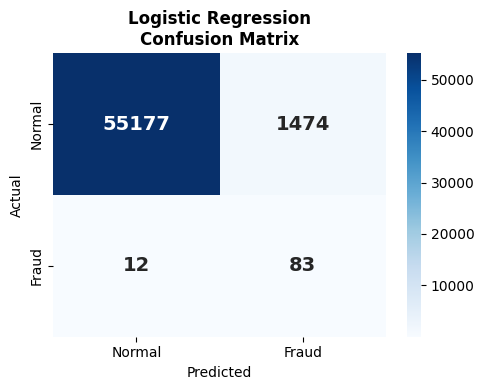

0.10048426150121065

In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — MODEL 1: LOGISTIC REGRESSION (Baseline)       ║
# ╚══════════════════════════════════════════════════════════╝
print("Training Logistic Regression (baseline)...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", lr, X_test, y_test, y_pred_lr, y_prob_lr)

Training KNN...

  MODEL: KNN (k=7)
  Accuracy  : 0.9952  (99.52%)
  Precision : 0.2381
  Recall    : 0.8421   ← Kitne fraud pakde
  F1-Score  : 0.3712
  AUC-ROC   : 0.9252

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.24      0.84      0.37        95

    accuracy                           1.00     56746
   macro avg       0.62      0.92      0.68     56746
weighted avg       1.00      1.00      1.00     56746



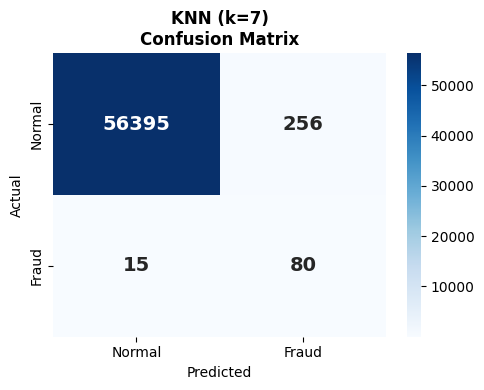

0.37122969837587005

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — MODEL 2: KNN                                 ║
# ╚══════════════════════════════════════════════════════════╝
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]
evaluate_model("KNN (k=7)", knn, X_test, y_test, y_pred_knn, y_prob_knn)

Training Naive Bayes...

  MODEL: Naive Bayes
  Accuracy  : 0.9764  (97.64%)
  Precision : 0.0550
  Recall    : 0.8105   ← Kitne fraud pakde
  F1-Score  : 0.1031
  AUC-ROC   : 0.9437

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56651
       Fraud       0.06      0.81      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746



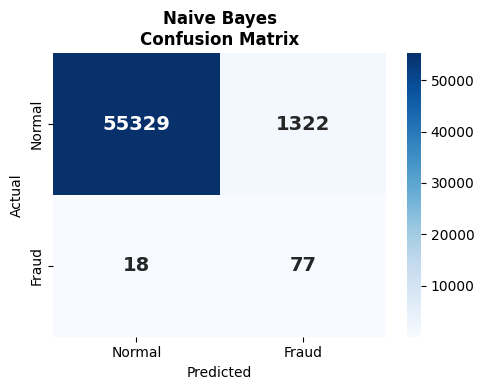

0.10307898259705489

In [15]:

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — MODEL 3: NAIVE BAYES                         ║
# ╚══════════════════════════════════════════════════════════╝
print("Training Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]
evaluate_model("Naive Bayes", nb, X_test, y_test, y_pred_nb, y_prob_nb)


Training SVM ...

  MODEL: SVM (RBF kernel)
  Accuracy  : 0.9849  (98.49%)
  Precision : 0.0886
  Recall    : 0.8632   ← Kitne fraud pakde
  F1-Score  : 0.1606
  AUC-ROC   : 0.9603

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56651
       Fraud       0.09      0.86      0.16        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.58     56746
weighted avg       1.00      0.98      0.99     56746



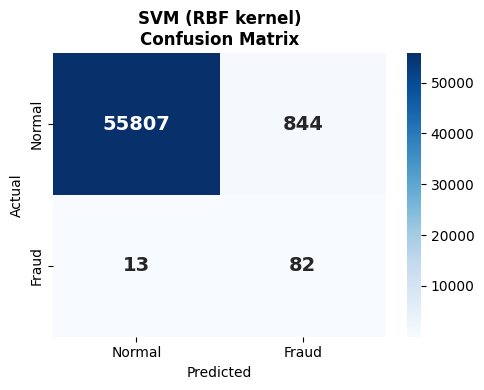

0.16062683643486778

In [16]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — MODEL 4: SVM                                 ║
# ╚══════════════════════════════════════════════════════════╝
print("Training SVM ...")
# Use subset for speed; full balanced data is large for SVM
svm = SVC(kernel='rbf', probability=True, random_state=42, C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]
evaluate_model("SVM (RBF kernel)", svm, X_test, y_test, y_pred_svm, y_prob_svm)

Training Random Forest...

  MODEL: Random Forest
  Accuracy  : 0.9993  (99.93%)
  Precision : 0.7812
  Recall    : 0.7895   ← Kitne fraud pakde
  F1-Score  : 0.7853
  AUC-ROC   : 0.9788

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.78      0.79      0.79        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



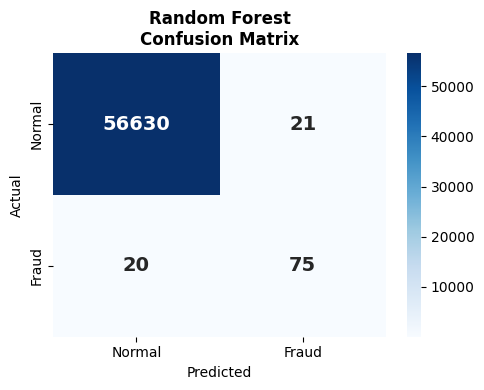

0.7853403141361257

In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — MODEL 5: RANDOM FOREST                       ║
# ╚══════════════════════════════════════════════════════════╝
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", rf, X_test, y_test, y_pred_rf, y_prob_rf)


Training XGBoost...

  MODEL: XGBoost
  Accuracy  : 0.9987  (99.87%)
  Precision : 0.5846
  Recall    : 0.8000   ← Kitne fraud pakde
  F1-Score  : 0.6756
  AUC-ROC   : 0.9723

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.58      0.80      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



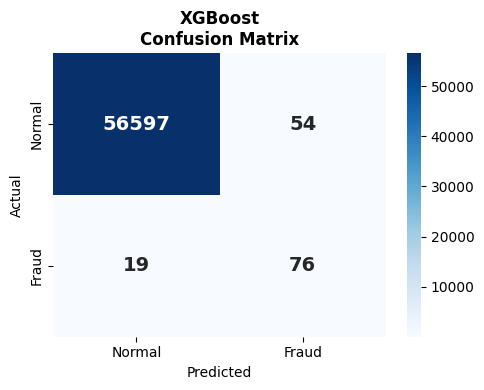

0.6755555555555556

In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 14 — MODEL 6: XGBOOST                             ║
# ╚══════════════════════════════════════════════════════════╝
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", xgb_model, X_test, y_test, y_pred_xgb, y_prob_xgb)

Training Neural Network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 51,969 (203.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9460 - auc: 0.9894 - loss: 0.1326 - val_accuracy: 0.9718 - val_auc: 0.9980 - val_loss: 0.0832 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9865 - auc: 0.9989 - loss: 0.0366 - val_accuracy: 0.9905 - val_auc: 0.9995 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9933 - auc: 0.9995 - loss: 0.0205 - val_accuracy: 0.9959 - val_auc: 0.9998 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9957 - auc: 0.9996 - loss: 0.0139 - val_accuracy: 0.9977 - val_auc: 0.9999 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9970 - auc: 0.9997 - loss: 0.0102 - val_accuracy: 0.9981 - val_auc: 0.9999 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9977 - auc: 0.9997 -

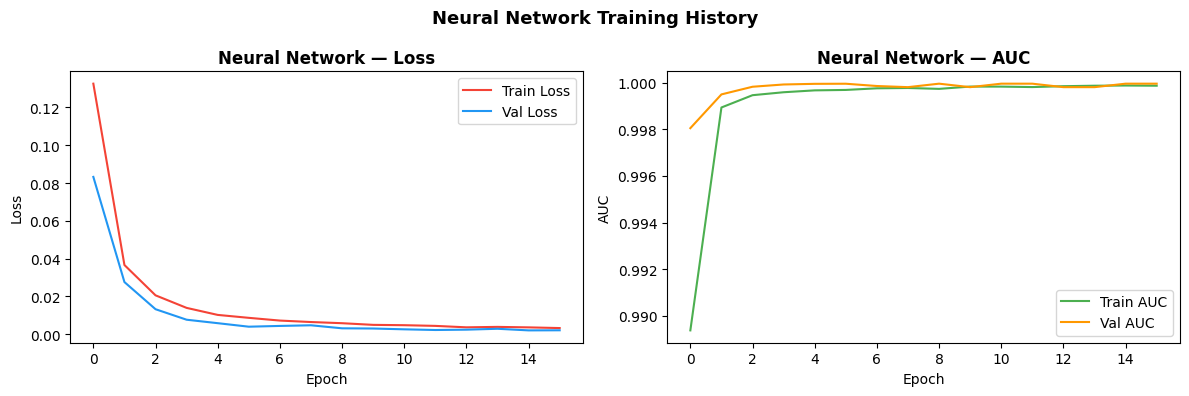


  MODEL: Neural Network
  Accuracy  : 0.9982  (99.82%)
  Precision : 0.4843
  Recall    : 0.8105   ← Kitne fraud pakde
  F1-Score  : 0.6063
  AUC-ROC   : 0.9430

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.48      0.81      0.61        95

    accuracy                           1.00     56746
   macro avg       0.74      0.90      0.80     56746
weighted avg       1.00      1.00      1.00     56746



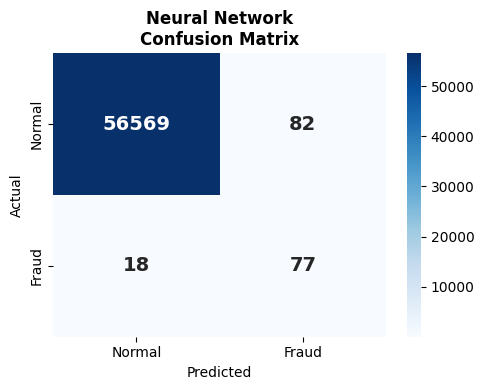

0.6062992125984252

In [19]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 15 — MODEL 7: NEURAL NETWORK (Deep Learning)      ║
# ╚══════════════════════════════════════════════════════════╝
print("Training Neural Network...")

# Convert to numpy if needed
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
X_test_np  = X_test.values  if hasattr(X_test,  'values') else X_test
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
y_test_np  = y_test.values  if hasattr(y_test,  'values') else y_test

# Build model
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

nn_model = build_nn(X_train_np.shape[1])
nn_model.summary()

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history = nn_model.fit(
    X_train_np, y_train_np,
    epochs=30,
    batch_size=2048,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train Loss', color='#F44336')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#2196F3')
axes[0].set_title('Neural Network — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC', color='#4CAF50')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#FF9800')
axes[1].set_title('Neural Network — AUC', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
plt.suptitle('Neural Network Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

y_prob_nn = nn_model.predict(X_test_np, verbose=0).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
evaluate_model("Neural Network", nn_model, X_test_np, y_test_np, y_pred_nn, y_prob_nn)

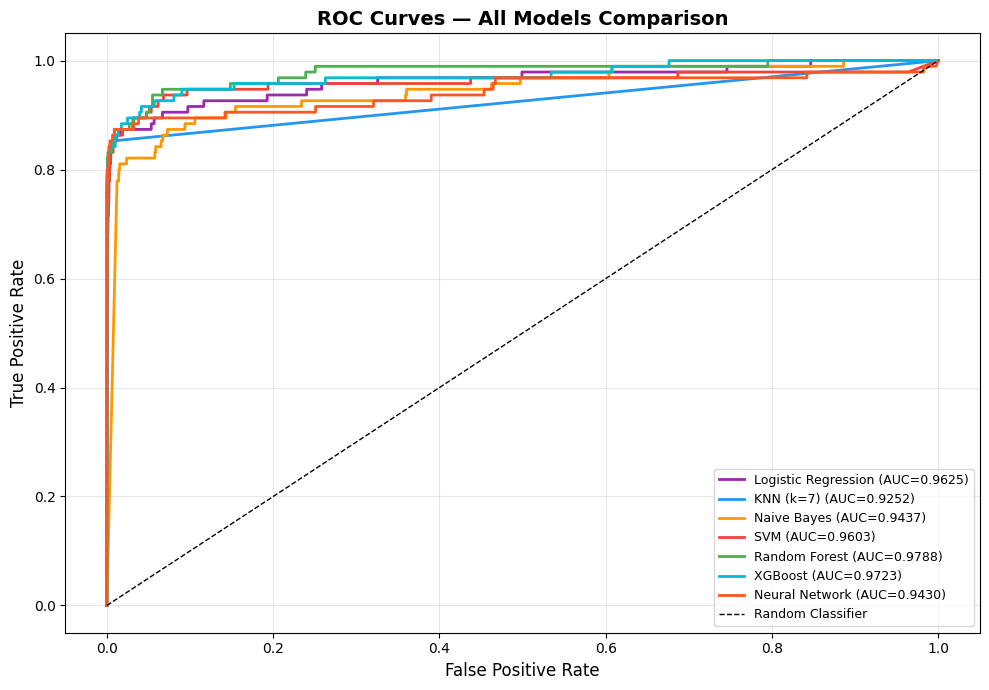

In [20]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 16 — ROC CURVES (All Models)                      ║
# ╚══════════════════════════════════════════════════════════╝
plt.figure(figsize=(10, 7))
colors = ['#9C27B0', '#2196F3', '#FF9800', '#F44336', '#4CAF50', '#00BCD4', '#FF5722']

model_probs = {
    'Logistic Regression': y_prob_lr,
    'KNN (k=7)':           y_prob_knn,
    'Naive Bayes':         y_prob_nb,
    'SVM':                 y_prob_svm,
    'Random Forest':       y_prob_rf,
    'XGBoost':             y_prob_xgb,
    'Neural Network':      y_prob_nn,
}

for (name, probs), color in zip(model_probs.items(), colors):
    yt = y_test_np if name == 'Neural Network' else np.array(y_test)
    fpr, tpr, _ = roc_curve(yt, probs)
    auc = roc_auc_score(yt, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

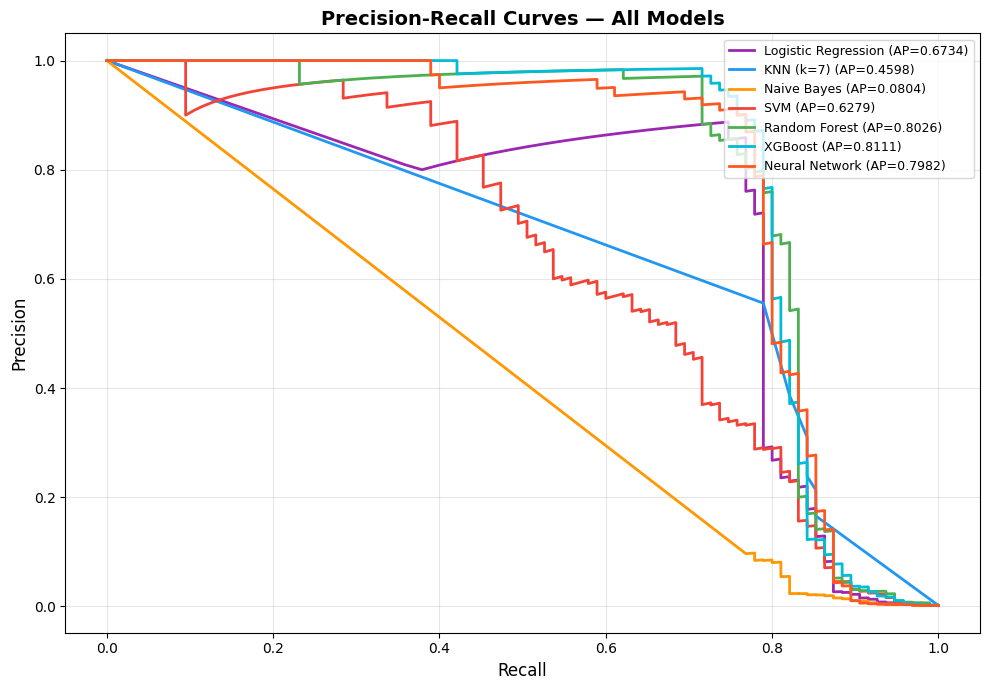

In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 17 — PRECISION-RECALL CURVES                      ║
# ╚══════════════════════════════════════════════════════════╝
plt.figure(figsize=(10, 7))

for (name, probs), color in zip(model_probs.items(), colors):
    yt = y_test_np if name == 'Neural Network' else np.array(y_test)
    prec_c, rec_c, _ = precision_recall_curve(yt, probs)
    ap = average_precision_score(yt, probs)
    plt.plot(rec_c, prec_c, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


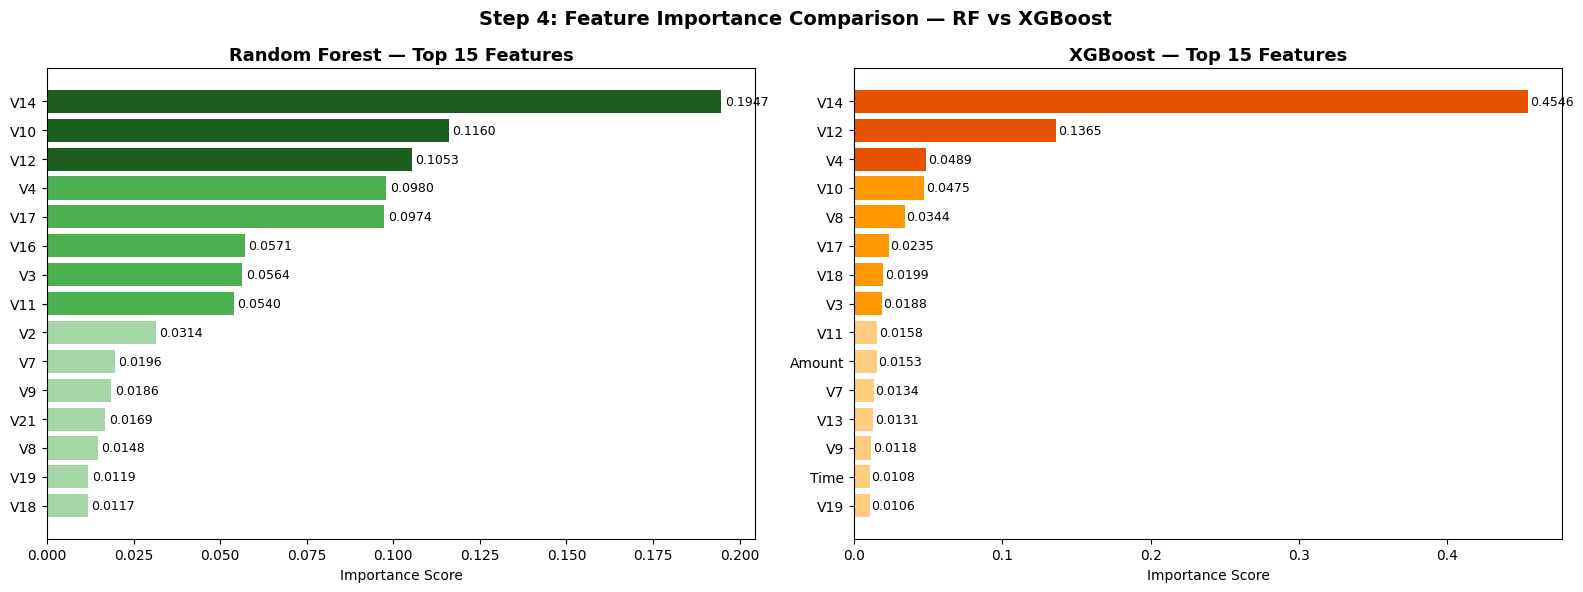


Top features common to both RF and XGBoost: ['V10', 'V11', 'V12', 'V14', 'V17', 'V3', 'V4']


In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 18 — FEATURE IMPORTANCE (RF + XGBoost)            ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
colors_rf = ['#1B5E20' if i < 3 else '#4CAF50' if i < 8 else '#A5D6A7' for i in range(15)]
axes[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color=colors_rf[::-1])
axes[0].set_title('Random Forest — Top 15 Features', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(rf_imp.values[::-1], rf_imp.index[::-1])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
colors_xgb = ['#E65100' if i < 3 else '#FF9800' if i < 8 else '#FFCC80' for i in range(15)]
axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color=colors_xgb[::-1])
axes[1].set_title('XGBoost — Top 15 Features', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(xgb_imp.values[::-1], xgb_imp.index[::-1])):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Step 4: Feature Importance Comparison — RF vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Common top features between RF and XGBoost
top_rf  = set(rf_imp.head(10).index)
top_xgb = set(xgb_imp.head(10).index)
common  = top_rf & top_xgb
print(f"\nTop features common to both RF and XGBoost: {sorted(common)}")


  THRESHOLD TUNING — Improve Low F1 Models

Model                    Default F1  Best Threshold   Tuned F1     Gain
----------------------------------------------------------------------
Logistic Regression          0.1005            0.89     0.3143  +0.2139
Naive Bayes                  0.1031            0.89     0.1097  +0.0066
SVM (RBF kernel)             0.1606            0.89     0.3173  +0.1566

Threshold tuning complete! Results updated.


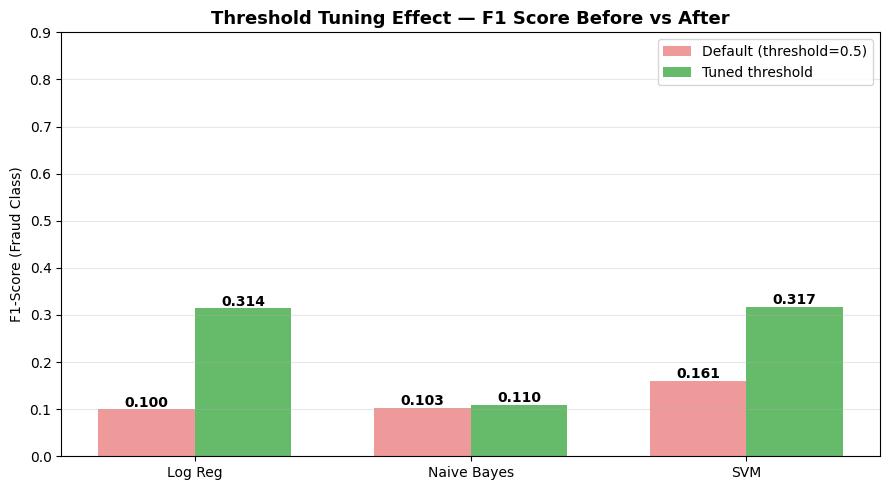

In [23]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 18B — THRESHOLD TUNING (Fix Low F1 Models)        ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*55)
print("  THRESHOLD TUNING — Improve Low F1 Models")
print("="*55)

from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold(y_true, y_prob, model_name):
    """Find threshold that maximizes F1-score for fraud class"""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = t
    return best_t, best_f1

# Apply to weak models
weak_models = {
    'Logistic Regression': (y_prob_lr, np.array(y_test)),
    'Naive Bayes':         (y_prob_nb, np.array(y_test)),
    'SVM (RBF kernel)':    (y_prob_svm, np.array(y_test)),
}

print(f"\n{'Model':<22} {'Default F1':>12} {'Best Threshold':>15} {'Tuned F1':>10} {'Gain':>8}")
print("-" * 70)

for name, (y_prob, y_true) in weak_models.items():
    default_f1 = results[name]['F1']
    best_t, tuned_f1 = find_best_threshold(y_true, y_prob, name)
    gain = tuned_f1 - default_f1
    print(f"{name:<22} {default_f1:>12.4f} {best_t:>15.2f} {tuned_f1:>10.4f} {'+'+str(round(gain,4)):>8}")

    # Update predictions with best threshold
    y_pred_tuned = (y_prob >= best_t).astype(int)
    results[name + ' (tuned)'] = {
        'Accuracy':  accuracy_score(y_true, y_pred_tuned),
        'Precision': precision_score(y_true, y_pred_tuned, zero_division=0),
        'Recall':    recall_score(y_true, y_pred_tuned),
        'F1':        tuned_f1,
        'AUC-ROC':   results[name]['AUC-ROC'],
        'y_pred':    y_pred_tuned,
        'y_prob':    y_prob
    }

print("\nThreshold tuning complete! Results updated.")

# Plot: Default vs Tuned F1 comparison
tuned_pairs = [
    ('Logistic Regression', 'Logistic Regression (tuned)'),
    ('Naive Bayes',         'Naive Bayes (tuned)'),
    ('SVM (RBF kernel)',    'SVM (RBF kernel) (tuned)'),
]

model_labels = ['Log Reg', 'Naive Bayes', 'SVM']
default_f1s  = [results[p[0]]['F1'] for p in tuned_pairs]
tuned_f1s    = [results[p[1]]['F1'] for p in tuned_pairs]

x = np.arange(len(model_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, default_f1s, width, label='Default (threshold=0.5)', color='#EF9A9A')
bars2 = ax.bar(x + width/2, tuned_f1s,   width, label='Tuned threshold', color='#66BB6A')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel('F1-Score (Fraud Class)')
ax.set_title('Threshold Tuning Effect — F1 Score Before vs After',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Cross Validation — 5-Fold (using 50,000 balanced samples for speed)

Training: Random Forest ...
  F1  : [0.997 0.999 0.997 0.999 0.999]  →  Mean: 0.9983 ± 0.0009
  Acc : [0.9971 0.9988 0.9973 0.9989 0.9994] →  Mean: 0.9983

Training: XGBoost ...
  F1  : [0.999 0.999 0.999 0.999 0.999]  →  Mean: 0.9990 ± 0.0001
  Acc : [0.999  0.9992 0.999  0.9989 0.999 ] →  Mean: 0.9990

Training: Neural Network (LR proxy) ...
  F1  : [0.943 0.946 0.944 0.951 0.95 ]  →  Mean: 0.9471 ± 0.0031
  Acc : [0.9451 0.9477 0.9457 0.9522 0.9516] →  Mean: 0.9485


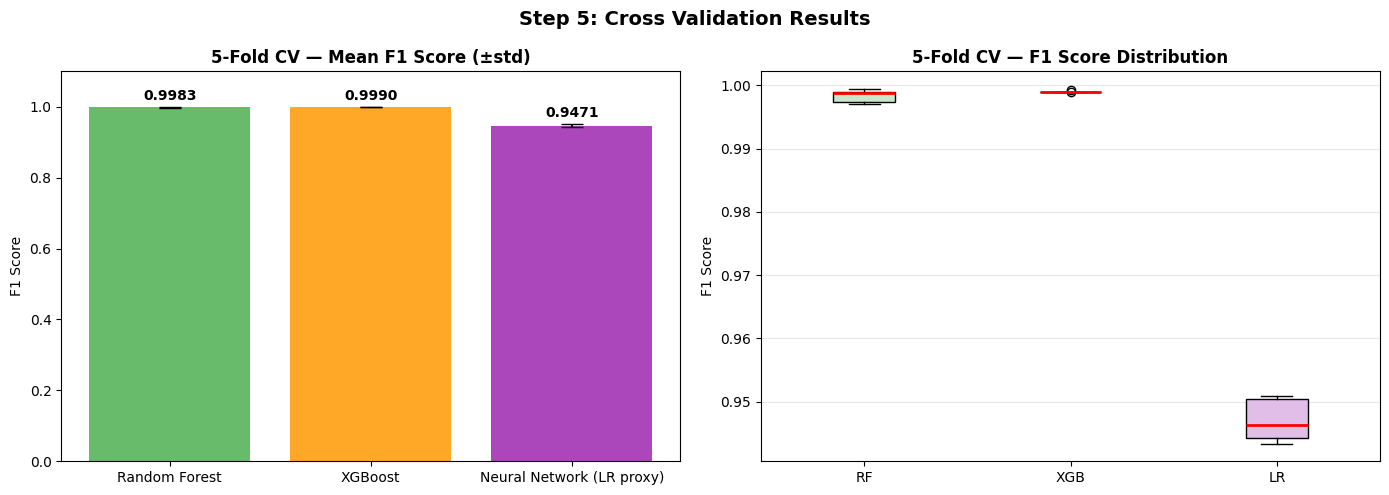

In [24]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 19 — CROSS VALIDATION (Best 2 Models)             ║
# ╚══════════════════════════════════════════════════════════╝
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb

print("Cross Validation — 5-Fold (using 50,000 balanced samples for speed)")
print("=" * 60)

# Balanced subset for CV
np.random.seed(42)
idx_0_cv = np.where(np.array(y_train) == 0)[0]
idx_1_cv = np.where(np.array(y_train) == 1)[0]
cv_size  = min(25000, len(idx_0_cv), len(idx_1_cv))

sel_0 = np.random.choice(idx_0_cv, cv_size, replace=False)
sel_1 = np.random.choice(idx_1_cv, cv_size, replace=False)
cv_idx = np.concatenate([sel_0, sel_1])
np.random.shuffle(cv_idx)

X_cv = X_train.iloc[cv_idx].reset_index(drop=True)
y_cv = y_train.iloc[cv_idx].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':       xgb.XGBClassifier(n_estimators=100, use_label_encoder=False,
                                        eval_metric='logloss', random_state=42, n_jobs=-1),
    'Neural Network (LR proxy)': LogisticRegression(max_iter=500, random_state=42),
}

cv_results_data = {}
for name, model in cv_models.items():
    print(f"\nTraining: {name} ...")
    f1_scores_cv  = cross_val_score(model, X_cv, y_cv, cv=skf, scoring='f1',       n_jobs=-1)
    acc_scores_cv = cross_val_score(model, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results_data[name] = {'f1': f1_scores_cv, 'acc': acc_scores_cv}
    print(f"  F1  : {f1_scores_cv.round(3)}  →  Mean: {f1_scores_cv.mean():.4f} ± {f1_scores_cv.std():.4f}")
    print(f"  Acc : {acc_scores_cv.round(4)} →  Mean: {acc_scores_cv.mean():.4f}")

# Cross Validation Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cv_names    = list(cv_results_data.keys())
cv_f1_means = [cv_results_data[n]['f1'].mean() for n in cv_names]
cv_f1_stds  = [cv_results_data[n]['f1'].std()  for n in cv_names]

axes[0].bar(cv_names, cv_f1_means, yerr=cv_f1_stds, capsize=8,
            color=['#4CAF50', '#FF9800', '#9C27B0'], alpha=0.85)
axes[0].set_title('5-Fold CV — Mean F1 Score (±std)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.1)
for i, (m, s) in enumerate(zip(cv_f1_means, cv_f1_stds)):
    axes[0].text(i, m + s + 0.02, f'{m:.4f}', ha='center', fontweight='bold')

# Box plots
box_data = [cv_results_data[n]['f1'] for n in cv_names]
bp = axes[1].boxplot(box_data, labels=['RF', 'XGB', 'LR'], patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors_bp = ['#C8E6C9', '#FFE0B2', '#E1BEE7']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1].set_title('5-Fold CV — F1 Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Step 5: Cross Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

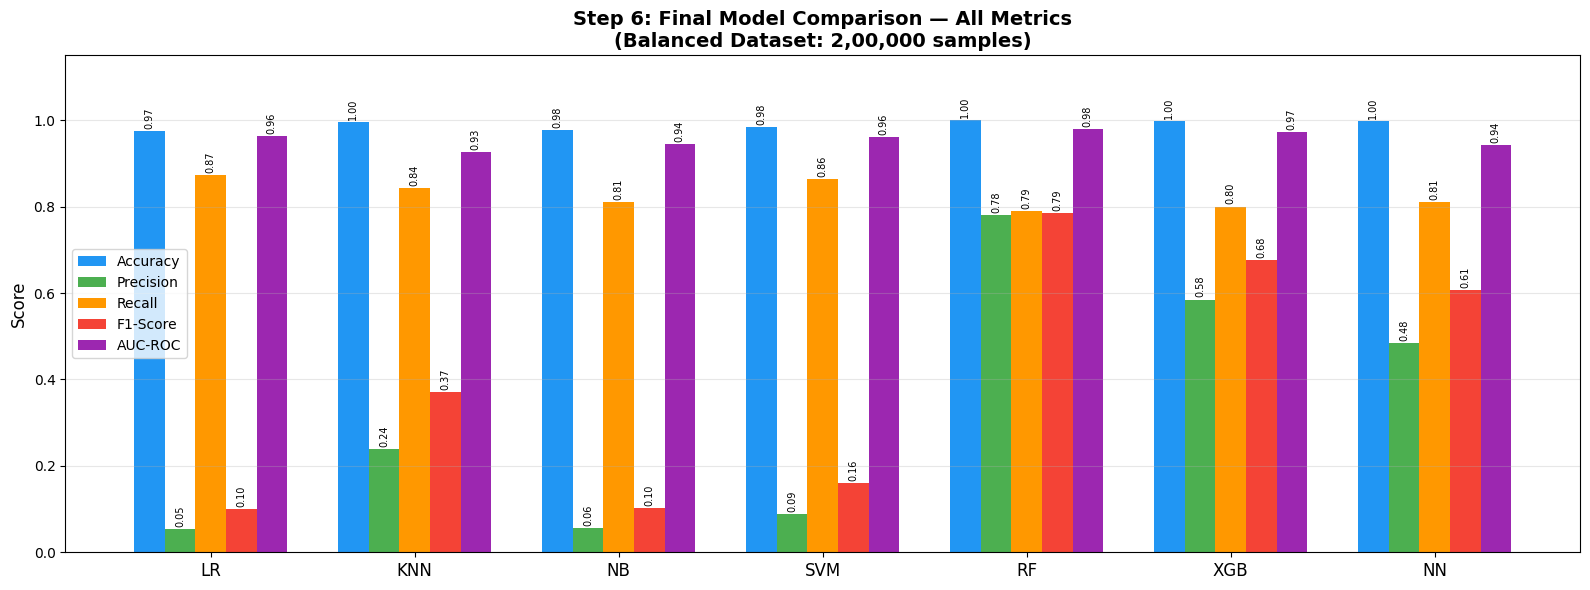

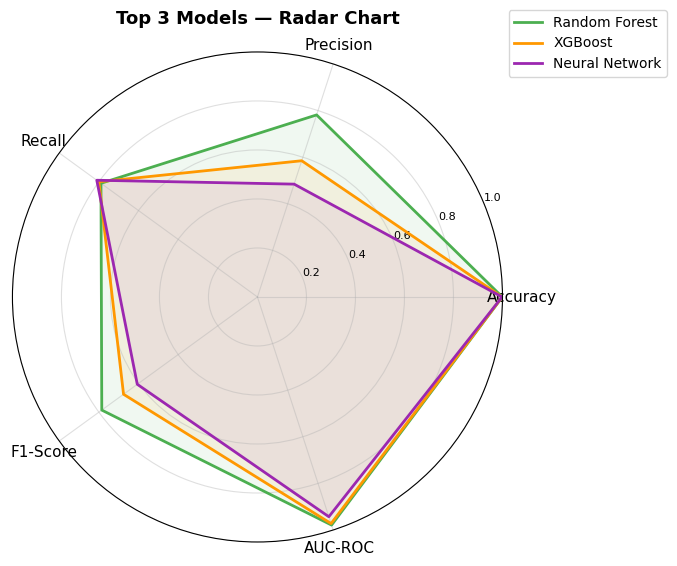

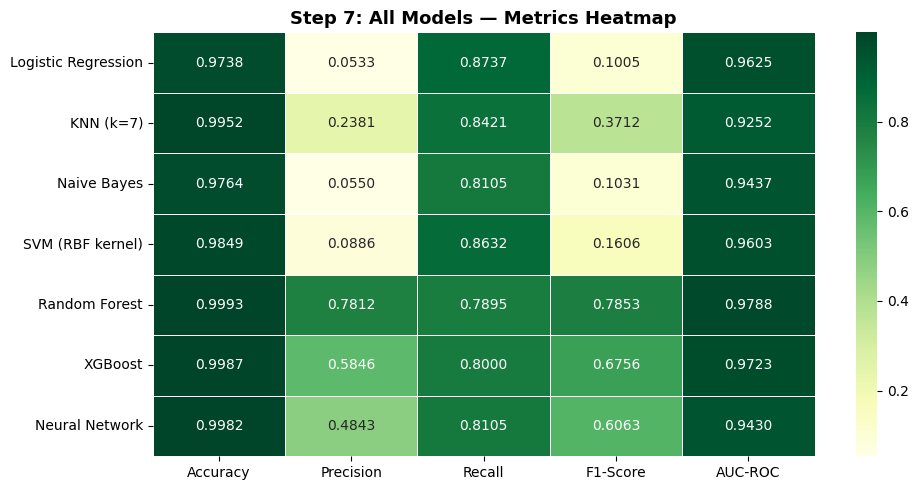


              FINAL RESULTS TABLE
Model                    Accuracy  Precision   Recall       F1      AUC
------------------------------------------------------------------------
Logistic Regression        0.9738     0.0533   0.8737   0.1005   0.9625
KNN (k=7)                  0.9952     0.2381   0.8421   0.3712   0.9252
Naive Bayes                0.9764     0.0550   0.8105   0.1031   0.9437
SVM (RBF kernel)           0.9849     0.0886   0.8632   0.1606   0.9603
Random Forest              0.9993     0.7812   0.7895   0.7853   0.9788 ⭐
XGBoost                    0.9987     0.5846   0.8000   0.6756   0.9723
Neural Network             0.9982     0.4843   0.8105   0.6063   0.9430

Best Model (by F1): Random Forest  |  F1 = 0.7853  |  AUC = 0.9788


In [25]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 20 — FINAL MODEL COMPARISON (3 Charts)            ║
# ╚══════════════════════════════════════════════════════════╝

final_models = ['Logistic Regression', 'KNN (k=7)', 'Naive Bayes',
                'SVM (RBF kernel)', 'Random Forest', 'XGBoost', 'Neural Network']

acc_list  = [results[m]['Accuracy']  for m in final_models]
prec_list = [results[m]['Precision'] for m in final_models]
rec_list  = [results[m]['Recall']    for m in final_models]
f1_list   = [results[m]['F1']        for m in final_models]
auc_list  = [results[m]['AUC-ROC']   for m in final_models]
short_names = ['LR', 'KNN', 'NB', 'SVM', 'RF', 'XGB', 'NN']

# ---- Chart 1: Grouped Bar — All Metrics ----
x     = np.arange(len(short_names))
width = 0.15
fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - 2*width, acc_list,  width, label='Accuracy',  color='#2196F3')
b2 = ax.bar(x - 1*width, prec_list, width, label='Precision', color='#4CAF50')
b3 = ax.bar(x + 0*width, rec_list,  width, label='Recall',    color='#FF9800')
b4 = ax.bar(x + 1*width, f1_list,   width, label='F1-Score',  color='#F44336')
b5 = ax.bar(x + 2*width, auc_list,  width, label='AUC-ROC',   color='#9C27B0')
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Step 6: Final Model Comparison — All Metrics\n(Balanced Dataset: 2,00,000 samples)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3, b4, b5]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
plt.show()

# ---- Chart 2: Radar Chart — Top 3 Models ----
categories  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
top3_models = ['Random Forest', 'XGBoost', 'Neural Network']
top3_colors = ['#4CAF50', '#FF9800', '#9C27B0']
top3_data   = [
    [results[m]['Accuracy'], results[m]['Precision'],
     results[m]['Recall'],   results[m]['F1'],   results[m]['AUC-ROC']]
    for m in top3_models
]

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(alpha=0.4)

for model, color, data in zip(top3_models, top3_colors, top3_data):
    vals = data + data[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=model)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_title('Top 3 Models — Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

# ---- Chart 3: Metrics Heatmap — All Models ----
import pandas as pd
metric_df = pd.DataFrame({
    'Accuracy':  acc_list,
    'Precision': prec_list,
    'Recall':    rec_list,
    'F1-Score':  f1_list,
    'AUC-ROC':   auc_list
}, index=final_models)

plt.figure(figsize=(10, 5))
sns.heatmap(metric_df, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 10})
plt.title('Step 7: All Models — Metrics Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final summary table
print("\n" + "=" * 72)
print("              FINAL RESULTS TABLE")
print("=" * 72)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 72)
for m, acc, p, r, f, a in zip(final_models, acc_list, prec_list, rec_list, f1_list, auc_list):
    marker = " ⭐" if f == max(f1_list) else ""
    print(f"{m:<22} {acc:>10.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f} {a:>8.4f}{marker}")
print("=" * 72)
best_model = final_models[f1_list.index(max(f1_list))]
print(f"\nBest Model (by F1): {best_model}  |  F1 = {max(f1_list):.4f}  |  AUC = {auc_list[f1_list.index(max(f1_list))]:.4f}")


In [26]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 21 — SAVE BEST MODEL                              ║
# ╚══════════════════════════════════════════════════════════╝
import joblib

print("Saving models...")
joblib.dump(rf,        'best_model_random_forest.pkl')
joblib.dump(xgb_model, 'model_xgboost.pkl')
joblib.dump(scaler,    'scaler.pkl')
nn_model.save('model_neural_network.h5')

print("Saved:")
print("  best_model_random_forest.pkl")
print("  model_xgboost.pkl")
print("  model_neural_network.h5")
print("  scaler.pkl")

from google.colab import files
for fname in ['best_model_random_forest.pkl', 'model_xgboost.pkl', 'scaler.pkl']:
    files.download(fname)
print("Download started!")


Saving models...
Saved:
  best_model_random_forest.pkl
  model_xgboost.pkl
  model_neural_network.h5
  scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
